# Imports and prepare device
---

## Imports

In [1]:


# Imports
import torch
from torchvision import models, transforms
import cv2 as cv
import pandas as pd
import numpy as np
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

from monai.data import Dataset as mDataset
from monai.data import DataLoader as mDataLoader
from monai.data import CacheDataset

import monai.transforms as mt
from monai.data.utils import default_collate, list_data_collate
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

from IPython.display import display, clear_output

import os

As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension


## Prepare device

In [2]:
# Prepare cuda device (if it exists)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device : torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

movedToDevice = False

print("device: " + str(device))

13.0
True
NVIDIA GeForce RTX 4060 Laptop GPU
device: cuda


# CLASIFICATION TRAINING
---

## Aux Functions

---

In [3]:
def get_class_names(dataset):
    # Works for ImageFolder, Subset, ConcatDataset
    if hasattr(dataset, 'class_to_idx'):
        class_to_idx = dataset.class_to_idx
    elif hasattr(dataset, 'dataset'):  # Subset
        return get_class_names(dataset.dataset)
    elif hasattr(dataset, 'datasets'):  # ConcatDataset
        return get_class_names(dataset.datasets[0])
    else:
        raise ValueError("Unsupported dataset type")

    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    return class_names

## Prepare training data

---

### Prepare transforms

Use different transforms to slowly adapt the image from more similar to imagenet data to data with more mri-like normalizations

In [4]:
# Prepare training data

# Define image transform for image normalization
classification_transform : transforms.Compose = transforms.Compose([
    transforms.Resize((224, 224)),        # Resize images to 224x224
    transforms.ToTensor(), # Transform back to tensor after applying augmentations
    transforms.Normalize(                 # Normalize like ImageNet
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])
# ^^^ Using ImageNet normalization to make it more compatible with the on ImageNet pretrained model

In [ ]:
# Redefine transform for full size images
classification_transform : transforms.Compose = transforms.Compose([
    transforms.Resize((512, 512)),        # Resize images to 512x512 instead of 224x224
    transforms.ToTensor(),                # Convert images to PyTorch tensors
    transforms.Normalize(                 # Normalize like ImageNet
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
# Redefine transform for full size images and standard MRI normalization instead of ImageNet normalization
# classification_transform : transforms.Compose = transforms.Compose([
#     transforms.Resize((512, 512)),        # Resize images to 512x512 (training image size)
#     transforms.ToTensor(),                # Convert images to PyTorch tensors
#     transforms.Lambda(lambda x: (x - x.mean()) / (x.std() + 1e-8)) # MRI normalization
# ])

classification_transform : mt.Compose = mt.Compose([
    mt.Lambda(lambda x: np.array(x)),   # PIL → NumPy
    mt.EnsureChannelFirst(channel_dim=-1),            # HWC → CHW
    mt.Resize((512,512)),
    mt.ToTensor(),
    mt.ThresholdIntensity(threshold=3.0, above=True, cval=0.0),
    mt.NormalizeIntensity(nonzero=True, channel_wise=True),
])

In [5]:

def get_label_distribution(loader):
    counter = Counter()
    for _, labels in loader:
        counter.update(labels.tolist())
    return counter

def get_label_distribution(loader, class_to_idx):
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    counter = Counter()
    for _, labels in loader:
        label_names = [idx_to_class[int(l)] for l in labels]
        counter.update(label_names)
    return counter

In [6]:
# Load Dataset

classification_dataset_1 : ImageFolder = ImageFolder(root="../Datasets/DATASET/classification/Training", transform=classification_transform)
classification_dataset_2 : ImageFolder = ImageFolder(root="../Datasets/brain_mir_classification_2", transform=classification_transform)

print(classification_dataset_1.class_to_idx)
print(classification_dataset_2.class_to_idx)

# For safety
assert classification_dataset_1.class_to_idx == classification_dataset_2.class_to_idx

classification_dataset : ConcatDataset = ConcatDataset([classification_dataset_1, classification_dataset_2])


# Split into training and validation (80/20 split) (we already have testing)
from torch.utils.data import random_split

train_size : int = int(0.8 * len(classification_dataset))
val_size : int = len(classification_dataset) - train_size

classification_train_dataset , classification_val_dataset = random_split(classification_dataset, [train_size, val_size])

classification_train_loader = DataLoader(classification_train_dataset, batch_size=32, shuffle=True)
classification_val_loader = DataLoader(classification_val_dataset, batch_size=32, shuffle=False)

print(classification_dataset.datasets[0].class_to_idx)


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
train_dist = get_label_distribution(classification_train_loader, classification_dataset_1.class_to_idx)
val_dist   = get_label_distribution(classification_val_loader, classification_dataset_1.class_to_idx)

print("Train label distribution:", train_dist)
print("Val label distribution:", val_dist)

print("Total images: ", sum(train_dist.values()) + sum(val_dist.values()))


### Change transforms of dataset to slowly adapt the data from imagenet-like to mri-like without changing the validation - trainign mix

In [ ]:
for d in classification_dataset.datasets:
    d.transform = classification_transform

In [ ]:
classification_dataset.transform = classification_transform

## Prepare model
---

In [7]:
# Grab resnet18 pretrained on imagenet
resnet : models.ResNet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) # Grab pre-trained model

In [8]:
# Change the last layer so it only gives 4 classes

num_classes : int = 4 # meningionma, pioma no tumor and whatever (its a variable in case it changes to yes/no)
in_features = resnet.fc.in_features # grab feature data so the new fc layer is the same

resnet.fc = torch.nn.Linear(in_features, num_classes) # replace fully connected layer so it outputs 4 classes instead of 600

In [9]:
# Freeze all layers except the new fully connected one
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

In [10]:
# optional -> move model to device
if(device):
    resnet = resnet.to(device)
    print("Moved to " + str(device))
    

Moved to cuda


## Finetune pre-trained ResNet18
----

### Define criterion and optimizer

In [11]:
# Define Loss and Optimizer
import torch.optim as optim

classification_criterion = torch.nn.CrossEntropyLoss()
classification_optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)  # only fc layer

### Training loop

Validating epoch 1: 100%|██████████| 81/81 [00:14<00:00,  5.69batch/s]

Epoch [1/5] Train Loss: 0.1694 | Train Acc: 0.9422 | Val Loss: 0.0641 | Val Acc: 0.9755


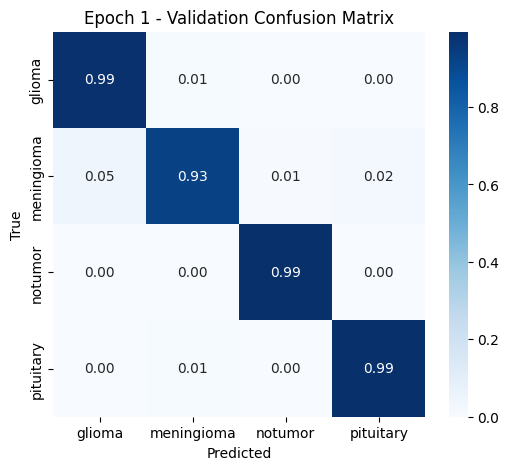

Validating epoch 2: 100%|██████████| 81/81 [00:16<00:00,  4.89batch/s]

Epoch [2/5] Train Loss: 0.0303 | Train Acc: 0.9899 | Val Loss: 0.0567 | Val Acc: 0.9825


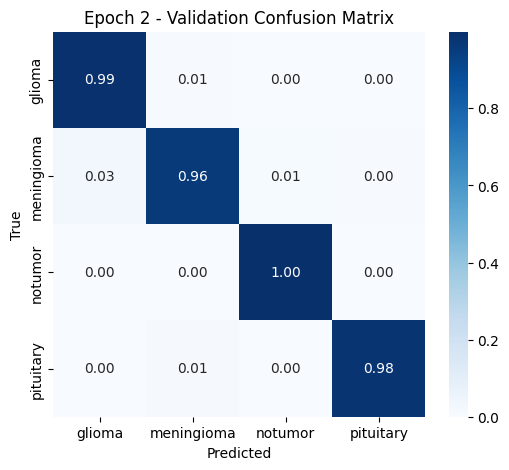

Validating epoch 3: 100%|██████████| 81/81 [00:12<00:00,  6.63batch/s]

Epoch [3/5] Train Loss: 0.0243 | Train Acc: 0.9906 | Val Loss: 0.0469 | Val Acc: 0.9880


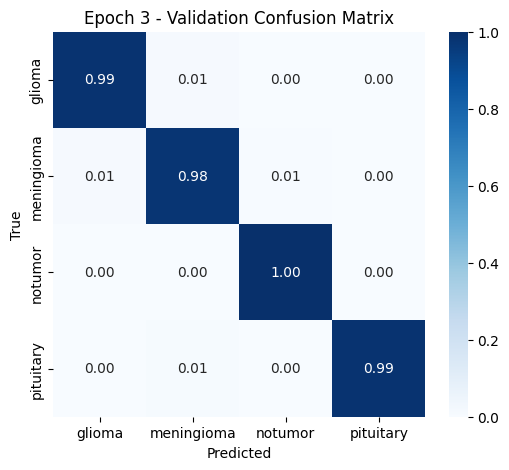

Validating epoch 4: 100%|██████████| 81/81 [00:18<00:00,  4.35batch/s]


Epoch [4/5] Train Loss: 0.0214 | Train Acc: 0.9912 | Val Loss: 0.0517 | Val Acc: 0.9852


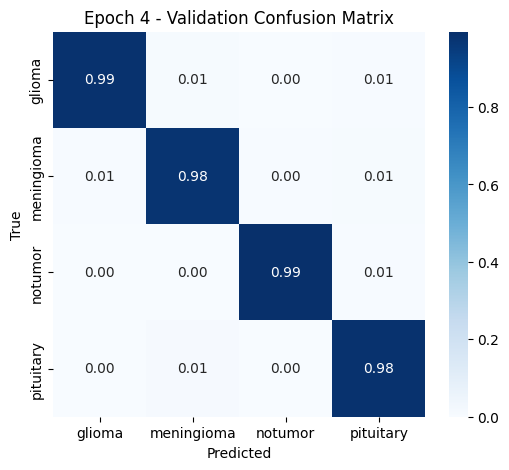

Validating epoch 5: 100%|██████████| 81/81 [00:19<00:00,  4.09batch/s]


Epoch [5/5] Train Loss: 0.0085 | Train Acc: 0.9971 | Val Loss: 0.0249 | Val Acc: 0.9914


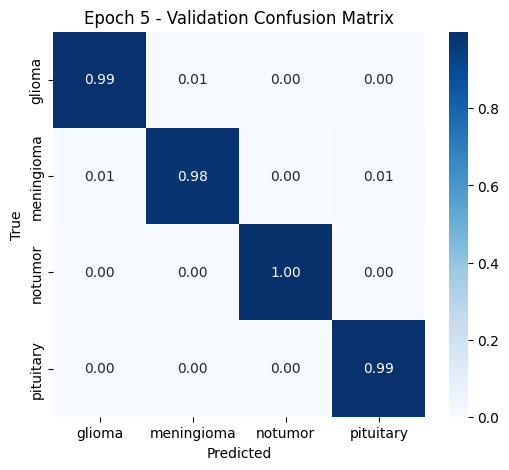

Training finished!


In [14]:
# Basic training loop
# Validates after each epoch to see progress (only doing so because its somehow fast)

num_epochs : int = 5

class_names = get_class_names(classification_train_dataset)

for epoch in range(num_epochs):
    resnet.train()
    classification_running_loss = 0.0
    classification_correct = 0
    classification_total = 0
    
    # ------------------ Training ------------------
    for images, labels in tqdm(classification_train_loader, desc="Training epoch " + str(epoch+1), unit="batch"):
        images, labels = images.to(device), labels.to(device)

        classification_optimizer.zero_grad()
        outputs = resnet(images)
        loss = classification_criterion(outputs, labels)
        loss.backward()
        classification_optimizer.step()

        classification_running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        classification_correct += predicted.eq(labels).sum().item()
        classification_total += labels.size(0)

    train_loss = classification_running_loss / classification_total
    train_acc = classification_correct / classification_total
    
    
    # ------------------ Validation ------------------    
    resnet.eval()
    classification_val_loss = 0.0
    classification_val_correct = 0
    classification_val_total = 0
    
    # Store predictions and labels for metrics
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(classification_val_loader, desc="Validating epoch " + str(epoch+1), unit="batch"):
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = classification_criterion(outputs, labels)
            
            classification_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            classification_val_correct += predicted.eq(labels).sum().item()
            classification_val_total += labels.size(0)
            
            # Store for metrics
            all_val_preds.append(predicted.cpu())
            all_val_labels.append(labels.cpu())

    classification_val_loss /= classification_val_total
    classification_val_acc = classification_val_correct / classification_val_total
    
    # Concatenate all batches
    all_val_preds = torch.cat(all_val_preds)
    all_val_labels = torch.cat(all_val_labels)

    # Compute confusion matrix
    cm = confusion_matrix(all_val_labels.numpy(), all_val_preds.numpy())
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    # Classification report (precision, recall, f1)
    report = classification_report(
        all_val_labels.numpy(),
        all_val_preds.numpy(),
        target_names=class_names,
        digits=4
    )

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {classification_val_loss:.4f} | Val Acc: {classification_val_acc:.4f}")

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Epoch {epoch+1} - Validation Confusion Matrix")
    plt.show()

print("Training finished!")

### Save or Load model weights

In [ ]:
# Save model

torch.save(resnet.state_dict(), "../saved_models/classification/resnet18_mri_fullytrained.pth")

In [ ]:
resnet.load_state_dict(state_dict= torch.load("../saved_models/resnet18_mri.pth"), strict = True)

### Change learning rate and frozen layers

Unfreeze everything except the last layer and the fc layer

In [13]:
# Change the learning ratio and unfreeze the layers to see how it evolves

# Freeze everything first
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in resnet.layer4.parameters():
    param.requires_grad = True

# FC layer is already trainable
for param in resnet.fc.parameters():
    param.requires_grad = True
    

classification_optimizer = torch.optim.Adam([
    {'params': resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet.fc.parameters(), 'lr': 1e-3}
])

Freeze everything except the last two layers and the fc layer. Put decreasingly low learning rates on the frozen layers (e-3 to the fc layer, e-4 to the last layer and e-5 to the third layer)

In [ ]:
# Change the learning ratio and unfreeze the layers to see how it evolves

# Freeze everything first
for param in resnet.parameters():
    param.requires_grad = False
    
for param in resnet.layer3.parameters():
    param.requires_grad = True

# Unfreeze last block
for param in resnet.layer4.parameters():
    param.requires_grad = True

# FC layer is already trainable
for param in resnet.fc.parameters():
    param.requires_grad = True
    

classification_optimizer = torch.optim.Adam([
    {'params': resnet.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet.fc.parameters(), 'lr': 1e-3}
])

## Testing

---

### Prepare testing dataset

In [20]:
# Load Test Dataset

classification_test_dataset : ImageFolder = ImageFolder(root="../Datasets/DATASET/classification/Testing", transform=classification_transform)

print(classification_test_dataset.class_to_idx)

classification_test_loader = DataLoader(classification_test_dataset, batch_size=32, shuffle=False)


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### Testing loop

Testing: 100%|██████████| 41/41 [00:46<00:00,  1.14s/batch]

Loss: 7.4189 | Acc: 0.3089
              precision    recall  f1-score   support

      glioma     0.0000    0.0000    0.0000       300
  meningioma     0.0000    0.0000    0.0000       306
     notumor     0.3089    1.0000    0.4720       405
   pituitary     0.0000    0.0000    0.0000       300

    accuracy                         0.3089      1311
   macro avg     0.0772    0.2500    0.1180      1311
weighted avg     0.0954    0.3089    0.1458      1311

Per-class Accuracy: [0. 0. 1. 0.]



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


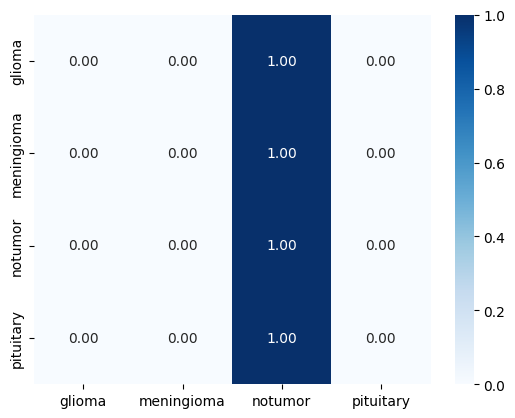

In [21]:
resnet.eval()

classification_test_loss = 0.0
classification_test_correct = 0
classification_test_total = 0

# Store predictions and labels
classification_test_all_preds = []
classification_test_all_labels = []

class_names = get_class_names(classification_test_dataset)

with torch.no_grad():
    for images, labels in tqdm(classification_test_loader, desc="Testing", unit="batch"):
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        
        
        loss = classification_criterion(outputs, labels)

        classification_test_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        classification_test_correct += predicted.eq(labels).sum().item()
        classification_test_total += labels.size(0)
        
        classification_test_all_preds.append(predicted.cpu())
        classification_test_all_labels.append(labels.cpu())

classification_test_loss /= classification_test_total
test_acc = classification_test_correct / classification_test_total

# Concatenate all batches
classification_test_all_preds = torch.cat(classification_test_all_preds)
classification_test_all_labels = torch.cat(classification_test_all_labels)

cm = confusion_matrix(classification_test_all_labels.numpy(), classification_test_all_preds.numpy())

per_class_acc = cm.diagonal() / cm.sum(axis=1)

report = classification_report(
    classification_test_all_labels.numpy(),
    classification_test_all_preds.numpy(),
    target_names=class_names,  
    digits=4
)

torch.save({'labels': classification_test_all_labels, 'preds': classification_test_all_preds}, 'test_preds.pt')

print(f"Loss: {classification_test_loss:.4f} | Acc: {test_acc:.4f}")
print(report)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)


print("Per-class Accuracy:", per_class_acc)

# SEGMENTATION TRAINING
---

## Prepare Custom ResUNet model
---

### Load model and prepare it
---

Create the model using a pre trained ResNet18, move it to the device of choice and freeze encoder layers (optionally)

In [3]:
# Grab resnet18 pretrained on imagenet
resnet : models.ResNet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) # Grab pre-trained model

# Change the last layer so it only gives 4 classes

num_classes : int = 4 #meningionma, pioma no tumor and whatever (its a variable in case it changes to yes/no)
in_features = resnet.fc.in_features # grab feature data so the new fc layer is the same

resnet.fc = torch.nn.Linear(in_features, num_classes) # replace fully connected layer so it outputs 4 classes instead of 600

In [4]:
resnet.load_state_dict(state_dict= torch.load("../saved_models/classification/resnet18_mri_fullytrained.pth"), strict = True)

<All keys matched successfully>

In [4]:
# custom model
from classes.ResUNet import ResUNet

# Load custom segmentation + classification model
resunet = ResUNet(resnet)

In [34]:
# optional -> move model to device
if(device):
    resunet = resunet.to(device)
    print("Moved to " + str(device))
    

Moved to cuda


In [33]:
# Freeze al encoder layers

for p in resunet.encoder_params:
    p.requires_grad = False

### Optionally load existing model
---

In [32]:
resunet.load_state_dict(state_dict= torch.load("../saved_models/segmentation/finetuned/288x288/resnet18_mri_seg_patch_best.pth"), strict = True)

<All keys matched successfully>

### Prepare Loss Functions for training, validation and testing
---

In [11]:
# Define criterions

# Define Loss and Optimizer

class_criterion = torch.nn.CrossEntropyLoss()
seg_criterion = torch.nn.BCEWithLogitsLoss()

TUMOR_CLASS_WEIGHTS = { # To fix class imbalance
    "Pituitary tumor": 1.0,
    "Meningioma": 1.6,
    "Glioma": 1.6,
}

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    loss = 1 - ((2.*intersection + smooth) / (union + smooth))
    return loss

def bce_dice_loss(pred, target, classes=None, alpha=0.5, smooth=1e-6):
    target = target.float()
    #---- Dice per sample ---
    dice = dice_loss(pred, target, smooth)
    
    #---- BCE (per pixel, per sample) ---
    bce = torch.nn.functional.binary_cross_entropy_with_logits(pred, target, reduction="none")
    bce = bce.view(bce.size(0), -1).mean(dim=1)
    
    # ---- Class weights ----
    weights = torch.tensor(
        [TUMOR_CLASS_WEIGHTS[c] for c in classes],
        device=pred.device
    ) if classes else 1
    loss = weights * (alpha * dice + (1 - alpha) * bce)
    
    return loss.mean()

optimizer_class = torch.optim.Adam(resunet.fc.parameters(), lr=1e-4)
optimizer_seg = torch.optim.Adam(resunet.decoder_params, lr=1e-3)

### Test to see **classification accuracy**
---

This part can be used after segmentation training to check how classification accuaracy was affected.

If the encoder was supposed to be frozen this will check that the classification capabilities didn't change.
If the encoder was also trained this will show how the segmentation afected the classification.

Testing: 100%|██████████| 41/41 [00:32<00:00,  1.27batch/s]


Loss: 0.0189 | Acc: 0.9947
              precision    recall  f1-score   support

      glioma     0.9967    0.9967    0.9967       300
  meningioma     0.9967    0.9804    0.9885       306
     notumor     1.0000    1.0000    1.0000       405
   pituitary     0.9836    1.0000    0.9917       300

    accuracy                         0.9947      1311
   macro avg     0.9942    0.9943    0.9942      1311
weighted avg     0.9947    0.9947    0.9947      1311

Per-class Accuracy: [0.99666667 0.98039216 1.         1.        ]


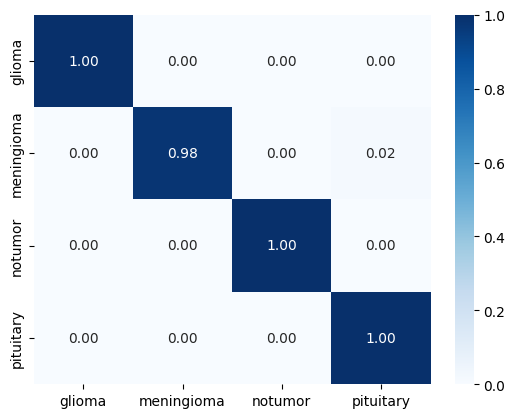

In [ ]:
# Test classification of ResUNet with classification test 

# Load Test Dataset

classification_test_transform : mt.Compose = mt.Compose([
    mt.Lambda(lambda x: np.array(x)),   # PIL → NumPy
    mt.EnsureChannelFirst(channel_dim=-1),            # HWC → CHW
    mt.Resize((512,512)),
    mt.ToTensor(),
    mt.ThresholdIntensity(threshold=3.0, above=True, cval=0.0),
    mt.NormalizeIntensity(nonzero=True, channel_wise=True),
])

test_dataset : ImageFolder = ImageFolder(root="../Datasets/DATASET/classification/Testing", transform=classification_test_transform)


image, label = test_dataset[0]

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# aux func

def get_class_names(dataset):
    # Works for ImageFolder, Subset, ConcatDataset
    if hasattr(dataset, 'class_to_idx'):
        class_to_idx = dataset.class_to_idx
    elif hasattr(dataset, 'dataset'):  # Subset
        return get_class_names(dataset.dataset)
    elif hasattr(dataset, 'datasets'):  # ConcatDataset
        return get_class_names(dataset.datasets[0])
    else:
        raise ValueError("Unsupported dataset type")

    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    return class_names


# Do Test

resunet.eval()
resunet.setModeOnlyClassification() # For faster classification

test_loss = 0.0
test_correct = 0
test_total = 0

# Store predictions and labels
all_preds = []
all_labels = []

class_names = get_class_names(test_dataset)

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing", unit="batch"):
        images, masks = images.to(device), masks.to(device)
        classification_outputs = resunet(images)
        
        
        loss = class_criterion(classification_outputs, masks)

        test_loss += loss.item() * images.size(0)
        _, predicted = classification_outputs.max(1)
        test_correct += predicted.eq(masks).sum().item()
        test_total += masks.size(0)
        
        all_preds.append(predicted.cpu())
        all_labels.append(masks.cpu())

test_loss /= test_total
test_acc = test_correct / test_total

# Concatenate all batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

per_class_acc = cm.diagonal() / cm.sum(axis=1)

report = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,  
    digits=4
)

report_for_latex = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,  
    digits=4,
    output_dict=True
)

torch.save({'labels': all_labels, 'preds': all_preds}, 'test_preds.pt')

print(f"Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")
print(report)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)


print("Per-class Accuracy:", per_class_acc)

df = pd.DataFrame(report_for_latex).transpose()
df.to_latex("classification_report.tex", float_format="%.4f")
df
# df.to_latex("classification_report.tex", float_format="%.4f")

## Prepare Data
---

### Data preparing aux function

In [8]:

# Build data list
from itertools import chain
import random

def return_data_list(*args, image_ext = ".png", divide_in_subsets = False):
    data = []
    for folder_dir in args:
        print(folder_dir)
        images = sorted([
            f for f in os.listdir(folder_dir)
            if f.endswith(image_ext) and not f.endswith("_mask" + image_ext)
        ])
        
        folder_name = os.path.basename(os.path.normpath(folder_dir))
        
        print(folder_name)
        
        for img_name in images:
            img = np.array(Image.open(os.path.join(folder_dir, img_name)).convert("RGB")) # [H, W, C]
            img = img.astype(np.float32)
            img = np.transpose(img, (2,0,1)) # [C, H, W]

            mask_name = img_name.replace(image_ext, "_mask" + image_ext)
            mask = np.array(Image.open(os.path.join(folder_dir, mask_name)).convert("L"))
            mask = (mask > 128).astype(np.uint8)
            mask = np.expand_dims(mask, axis=0) # [1, H, W] --> Adds channel
            
            data.append({
                "image": img,
                "label": mask,
                "class": folder_name
            })
    
    if not divide_in_subsets:
        return data

    train_size : int = int(0.8 * len(data))
    val_size : int = len(data) - train_size
    
    def random_split_list(data, lengths, seed=None):
        if sum(lengths) > len(data):
            raise ValueError("Sum of lengths cannot exceed data length")
        if seed is not None:
            random.seed(seed)
        shuffled = data.copy()
        random.shuffle(shuffled)
        splits = []
        start = 0
        for l in lengths:
            splits.append(shuffled[start:start+l])
            start += l
        return splits
    
    train_list, val_list = random_split_list(data, [train_size, val_size])
    
    return (train_list, val_list)

### For Whole Image Training
---

In [9]:
# Redefine transform for full size images and standard MRI normalization instead of ImageNet normalization


seg_training_wholeimage_transform = mt.Compose([
    mt.EnsureChannelFirstd(keys=["image", "label"], channel_dim=0),
    mt.EnsureTyped(keys=["image", "label"]),

    mt.ThresholdIntensityd(keys=["image"], threshold=3.0, above=True, cval=0.0),
    mt.NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
])


seg_validation_wholeimage_transforms = mt.Compose([
    mt.EnsureChannelFirstd(keys=["image", "label"], channel_dim=0),
    mt.EnsureTyped(keys=["image", "label"]),
    
    mt.ThresholdIntensityd(keys=["image"], threshold=3.0, above=True, cval=0.0),
    mt.NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
])


In [36]:


train_data, val_data = return_data_list(
    "../Datasets/DATASET/Segmentation/Glioma",
    "../Datasets/DATASET/Segmentation/Meningioma",
    "../Datasets/DATASET/Segmentation/Pituitary tumor",
    divide_in_subsets = True
)


../Datasets/DATASET/Segmentation/Glioma
Glioma
../Datasets/DATASET/Segmentation/Meningioma
Meningioma
../Datasets/DATASET/Segmentation/Pituitary tumor
Pituitary tumor


In [37]:
train_ds = mDataset(data=train_data, transform=seg_training_wholeimage_transform)
val_ds = mDataset(data=val_data, transform=seg_validation_wholeimage_transforms)

whole_image_train_loader = mDataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=default_collate)
whole_image_val_loader = mDataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=default_collate)

### For Patch Training
---

In [10]:
# Define Transforms

tumor_chance = 70
patch_xdim = 288
patch_ydim = 288
patch_dimensions = (patch_xdim,patch_ydim) # Try to keep it divisible between 32 (the dimension reduction rate of resnet18)
patch_ammount = 6

pos = int(round(tumor_chance))
neg = int(round(100 - tumor_chance))

seg_training_patch_transform = mt.Compose([
    mt.EnsureChannelFirstd(keys=["image", "label"], channel_dim=0),
    mt.EnsureTyped(keys=["image", "label"]),

    mt.Lambdad(
        keys="image",
        func=lambda x: (x - x.mean()) / (x.std() + 1e-8)
    ),

    mt.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size= [patch_xdim,patch_ydim],
        pos=pos,
        neg=neg,
        num_samples=patch_ammount,
    ),
])


seg_validation_patch_transforms = mt.Compose([
    mt.EnsureChannelFirstd(keys=["image", "label"], channel_dim=0),
    mt.EnsureTyped(keys=["image", "label"]),
    mt.Lambdad(keys="image", func=lambda x: (x - x.mean()) / (x.std() + 1e-8)),
])

In [11]:

# Build data list
from itertools import chain
import random

def return_data_list(*args, image_ext = ".png", divide_in_subsets = False):
    data = []
    for folder_dir in args:
        print(folder_dir)
        images = sorted([
            f for f in os.listdir(folder_dir)
            if f.endswith(image_ext) and not f.endswith("_mask" + image_ext)
        ])
        
        folder_name = os.path.basename(os.path.normpath(folder_dir))
        
        print(folder_name)
        
        for img_name in images:
            img = np.array(Image.open(os.path.join(folder_dir, img_name)).convert("RGB")) # [H, W, C]
            img = img.astype(np.float32)
            img = np.transpose(img, (2,0,1)) # [C, H, W]

            mask_name = img_name.replace(image_ext, "_mask" + image_ext)
            mask = np.array(Image.open(os.path.join(folder_dir, mask_name)).convert("L"))
            mask = (mask > 128).astype(np.uint8)
            mask = np.expand_dims(mask, axis=0) # [1, H, W] --> Adds channel
            
            data.append({
                "image": img,
                "label": mask,
                "class": folder_name
            })
    
    if not divide_in_subsets:
        return data

    train_size : int = int(0.8 * len(data))
    val_size : int = len(data) - train_size
    
    def random_split_list(data, lengths, seed=None):
        if sum(lengths) > len(data):
            raise ValueError("Sum of lengths cannot exceed data length")
        if seed is not None:
            random.seed(seed)
        shuffled = data.copy()
        random.shuffle(shuffled)
        splits = []
        start = 0
        for l in lengths:
            splits.append(shuffled[start:start+l])
            start += l
        return splits
    
    train_list, val_list = random_split_list(data, [train_size, val_size])
    
    return (train_list, val_list)

In [12]:
# Generate datasets

train_data, val_data = return_data_list(
    "../Datasets/DATASET/Segmentation/Glioma",
    "../Datasets/DATASET/Segmentation/Meningioma",
    "../Datasets/DATASET/Segmentation/Pituitary tumor",
    divide_in_subsets = True
)

../Datasets/DATASET/Segmentation/Glioma
Glioma
../Datasets/DATASET/Segmentation/Meningioma
Meningioma
../Datasets/DATASET/Segmentation/Pituitary tumor
Pituitary tumor


In [13]:
train_ds = mDataset(data=train_data, transform=seg_training_patch_transform)
val_ds = mDataset(data=val_data, transform=seg_validation_patch_transforms)

patch_train_loader = mDataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=list_data_collate)
patch_val_loader = mDataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=default_collate) # patch size 1 because of sliding window interface

## Train the model
---

### Define optimizers and loss functions


In [147]:
# -----------------------------
# Optimizer for Segmentation
# -----------------------------
# Train decoder and segmentation head only
optimizer_seg = torch.optim.Adam(resunet.decoder_params, lr=1e-3)

### Define Aux functions and variables for training

In [148]:
# Define structures of statistical data to save between training sessions

train_losses = []
val_losses = []

patch_train_losses = []
patch_val_losses = []

In [23]:
# Aux functions

def dice_score(preds, targets, smooth=1e-6):
    # preds, targets: [B,H,W] binary
    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2))

    dice = (2 * intersection + smooth) / (union + smooth)
    return dice 


def encoder_layer_into_eval(resUNetmodel : ResUNet):
    resUNetmodel.encoder0.eval()
    resUNetmodel.encoder1.eval()
    resUNetmodel.encoder2.eval()
    resUNetmodel.encoder3.eval()
    resUNetmodel.encoder4.eval()
    resUNetmodel.pool.eval()

def freeze_encoder_layer(resUNetmodel : ResUNet):
    for p in resUNetmodel.encoder0.parameters():
        p.requires_grad = False
    for p in resUNetmodel.encoder1.parameters():
        p.requires_grad = False
    for p in resUNetmodel.encoder2.parameters():
        p.requires_grad = False
    for p in resUNetmodel.encoder3.parameters():
        p.requires_grad = False
    for p in resUNetmodel.encoder4.parameters():
        p.requires_grad = False
    for p in resUNetmodel.pool.parameters():
        p.requires_grad = False

    # Put encoder into eval mode to freeze BatchNorm running stats
    encoder_layer_into_eval(resUNetmodel)

### Training Loops

#### For whole image training (not patch training)

Training epoch 1: 100%|██████████| 220/220 [01:48<00:00,  2.02batch/s]


Overall Loss: 0.5060


Validating epoch 1: 100%|██████████| 55/55 [00:24<00:00,  2.21batch/s]


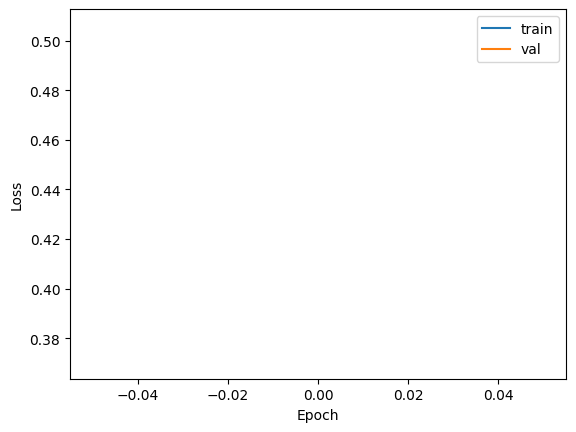

Overall Pixel Accuracy: 0.9864
Background Accuracy: 0.9957
Tumor Accuracy: 0.4536
Dice Coefficient: 0.4979
Validation Loss: 0.3704
Training finished!


In [150]:
# Train for segmentation

num_epochs : int = 1

training_only_decoder = True

resunet.float()


resunet.setModeOnlySegmentation()

# -----------------------------
# Freeze Encoder & BN Layers
# -----------------------------
# Freeze encoder weights
if training_only_decoder:
    freeze_encoder_layer(resunet)

for epoch in range(num_epochs):
    resunet.train()
    
    if training_only_decoder:
        encoder_layer_into_eval(resunet)
    
    correct = 0
    total = 0

    train_batch_losses = []
    
    # ------------------ Training ------------------
    for batch in tqdm(whole_image_train_loader, desc="Training epoch " + str(epoch + 1), unit="batch"):
        images, masks, classes = batch["image"].to(device), batch["label"].to(device) , batch["class"]

        optimizer_seg.zero_grad()
        segmentation_outputs = resunet(images)
        # loss = seg_criterion(segmentation_outputs, masks) + dice_loss(segmentation_outputs.unsqueeze(1), masks.unsqueeze(1))
        loss = bce_dice_loss(segmentation_outputs, masks,classes)
        loss.backward()
        optimizer_seg.step()

        train_batch_losses.append(loss.item())
        predicted = (torch.sigmoid(segmentation_outputs) > 0.5).long().squeeze(1)
        correct += (predicted == masks).float().sum().item()
        total += masks.numel()

    train_loss = sum(train_batch_losses) / len(train_batch_losses)
    train_losses.append(train_loss)
    train_acc = correct / total
    
    print(f"Overall Loss: {train_loss:.4f}")
    
    # ------------------ Validation ------------------    
    resunet.eval()
    
    all_dice = []
    all_pixel_acc = []
    all_bg_acc = []
    all_tumor_acc = []
    
    # Store predictions and labels for metrics
    all_val_preds = []
    all_val_labels = []
    
    val_batch_losses = []

    with torch.no_grad():
        for batch in tqdm(whole_image_val_loader, desc="Validating epoch " + str(epoch + 1), unit="batch"):
            images, masks, classes = batch["image"].to(device), batch["label"].to(device) , batch["class"]
            
            segmentation_outputs = resunet(images)
            
            loss = bce_dice_loss(segmentation_outputs, masks, classes)
            
            # Convert logits to probabilities then to binary prediction
            probs = torch.sigmoid(segmentation_outputs)
            preds = (probs > 0.5).long().squeeze(1)  # shape: [B,H,W]
            
            masks = masks.squeeze(1)
            
            # ---------- Pixel-wise accuracy ----------
            correct_pixels = (preds == masks).float()
            pixel_acc = correct_pixels.mean().item()
            all_pixel_acc.append(pixel_acc)
            
            # ---------- Per-class accuracy ----------
            bg_mask = masks == 0
            tumor_mask = masks == 1

            bg_acc = (preds[bg_mask] == 0).float().mean().item() if bg_mask.any() else 0
            
            tumor_acc = (preds[tumor_mask] == 1).float().mean().item() if tumor_mask.any() else 0

            all_bg_acc.append(bg_acc)
            all_tumor_acc.append(tumor_acc)
            
            # ---------- Dice ----------
            dice = dice_score(preds, masks)  # returns tensor of size [B]
            all_dice.extend(dice.cpu().numpy())
            
            # ---------- Loss ----------
            val_batch_losses.append(loss.item())

    # Aggregate results
    mean_pixel_acc = sum(all_pixel_acc) / len(all_pixel_acc)
    mean_bg_acc = sum(all_bg_acc) / len(all_bg_acc)
    mean_tumor_acc = sum(all_tumor_acc) / len(all_tumor_acc)
    mean_dice = sum(all_dice) / len(all_dice)
    
    validation_loss = sum(val_batch_losses) / len(val_batch_losses)
    val_losses.append(validation_loss)
    
    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f"Overall Pixel Accuracy: {mean_pixel_acc:.4f}")
    print(f"Background Accuracy: {mean_bg_acc:.4f}")
    print(f"Tumor Accuracy: {mean_tumor_acc:.4f}")
    print(f"Dice Coefficient: {mean_dice:.4f}")
    print(f"Validation Loss: {validation_loss:.4f}")

print("Training finished!")

#### For Patch Training

In [ ]:
# Train for segmentation

num_epochs : int = 10

training_only_decoder = True

resunet.setModeOnlySegmentation()

# -----------------------------
# Freeze Encoder & BN Layers
# -----------------------------
# Freeze encoder weights
if training_only_decoder:
    freeze_encoder_layer(resunet)

# -----------------------------
# Optimizer for Segmentation
# -----------------------------
# Train decoder and segmentation head only
optimizer_seg = torch.optim.Adam(resunet.decoder_params, lr=1e-3)

for epoch in range(num_epochs):
    resunet.train()
    
    if training_only_decoder:
        encoder_layer_into_eval(resunet)
    
    correct = 0
    total = 0

    train_batch_losses = []
    
    # ------------------ Training ------------------
    for batch in tqdm(patch_train_loader, desc="Training epoch " + str(epoch + 1), unit="batch"):
        images, masks, classes = batch["image"].to(device), batch["label"].to(device), batch["class"]

        optimizer_seg.zero_grad()
        segmentation_outputs = resunet(images)
        # loss = seg_criterion(segmentation_outputs, masks) + dice_loss(segmentation_outputs.unsqueeze(1), masks.unsqueeze(1))
        loss = bce_dice_loss(segmentation_outputs, masks, classes, 0.7)
        loss.backward()
        optimizer_seg.step()

        train_batch_losses.append(loss.item())
        predicted = (torch.sigmoid(segmentation_outputs) > 0.5).long().squeeze(1)
        correct += (predicted == masks).float().sum().item()
        total += masks.numel()

    train_loss = sum(train_batch_losses) / len(train_batch_losses)
    train_losses.append(train_loss)
    train_acc = correct / total
    
    print(f"Overall Pixel Accuracy: {train_acc:.4f}")
    print(f"Overall Loss: {train_loss:.4f}")
    
    # ------------------ Validation ------------------    
    resunet.eval()
    
    dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
    dice_metric_with_bg = DiceMetric(include_background=True, reduction="mean_batch")
    all_pixel_acc = []
    all_bg_acc = []
    all_tumor_acc = []
    
    # Store predictions and labels for metrics
    all_val_preds = []
    all_val_labels = []
    
    val_batch_losses = []
    
    # sliding window interfaze parameters
    roi_size = patch_dimensions  # same as training patches
    sw_batch_size = 4            # number of patches processed in parallel
    overlap = 0.5  # half of the patch is overlap

    with torch.no_grad():
        for batch in tqdm(patch_val_loader, desc="Validating epoch " + str(epoch + 1), unit="batch"):
            images, masks, classes = batch["image"].to(device), batch["label"].to(device), batch["class"]
            
            # ----------- Sliding window inference -----------
            
            segmentation_outputs = sliding_window_inference(
                inputs=images,
                roi_size=roi_size,
                sw_batch_size=sw_batch_size,
                predictor=resunet,
                overlap=overlap,
                mode='gaussian'
            )
            
            # ---------- Loss ----------
            loss = bce_dice_loss(segmentation_outputs, masks, classes, 0.7)
            val_batch_losses.append(loss.item())
            
            # Convert logits to probabilities then to binary prediction
            probs = torch.sigmoid(segmentation_outputs)
            preds = (probs > 0.5).long().squeeze(1)  # shape: [B,H,W]
            
            masks = masks.squeeze(1) # shape: [B,H,W]
            
            # ---------- Pixel-wise accuracy ----------
            correct_pixels = (preds == masks).float()
            pixel_acc = correct_pixels.mean().item()
            all_pixel_acc.append(pixel_acc)
            
            # ---------- Per-class accuracy ----------
            bg_mask = masks == 0
            tumor_mask = masks == 1

            bg_acc = (preds[bg_mask] == 0).float().mean().item() if bg_mask.any() else 0
            
            tumor_acc = (preds[tumor_mask] == 1).float().mean().item() if tumor_mask.any() else 0

            all_bg_acc.append(bg_acc)
            all_tumor_acc.append(tumor_acc)
            
            # ---------- Dice ----------
            preds = preds.unsqueeze(1)
            masks = masks.unsqueeze(1)
            dice_metric(y_pred=preds, y=masks)
            dice_metric_with_bg(y_pred=preds, y=masks)

    # Aggregate results
    mean_pixel_acc = sum(all_pixel_acc) / len(all_pixel_acc)
    mean_bg_acc = sum(all_bg_acc) / len(all_bg_acc)
    mean_tumor_acc = sum(all_tumor_acc) / len(all_tumor_acc)
    
    mean_dice = dice_metric.aggregate().item()
    mean_dice_with_bg = dice_metric_with_bg.aggregate().item()
    dice_metric.reset()
    dice_metric_with_bg.reset()
    
    validation_loss = sum(val_batch_losses) / len(val_batch_losses)
    val_losses.append(validation_loss)
    
    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f"Overall Pixel Accuracy: {mean_pixel_acc:.4f}")
    print(f"Background Accuracy: {mean_bg_acc:.4f}")
    print(f"Tumor Accuracy: {mean_tumor_acc:.4f}")
    print(f"Dice Coefficient (only tumor): {mean_dice:.4f}")
    print(f"Dice Coefficient (with background): {mean_dice_with_bg:.4f}")
    print(f"Validation Loss: {validation_loss:.4f}")

print("Training finished!")

### Only validation

In [ ]:
from collections import defaultdict



# ------------------ Validation ------------------    
resunet.eval()

dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
dice_metric_with_bg = DiceMetric(include_background=True, reduction="mean_batch")
dice_metric_per_sample = DiceMetric(
    include_background=False,
    reduction="none"
)
all_pixel_acc = []
all_bg_acc = []
all_tumor_acc = []

dice_by_class = defaultdict(list)

# Store predictions and labels for metrics
all_val_preds = []
all_val_labels = []

val_batch_losses = []

# sliding window interfaze parameters
roi_size = patch_dimensions  # same as training patches
sw_batch_size = 4            # number of patches processed in parallel
overlap = 0.5  # half of the patch is overlap

with torch.no_grad():
    for batch in tqdm(whole_image_val_loader, desc="Validating", unit="batch"):
        images, masks = batch["image"].to(device), batch["label"].to(device)
        
        classes = batch["class"]
    
        # ----------- Sliding window inference -----------
        
        # segmentation_outputs = sliding_window_inference(
        #     inputs=images,
        #     roi_size=roi_size,
        #     sw_batch_size=sw_batch_size,
        #     predictor=resunet,
        #     overlap=overlap,
        #     mode='gaussian'
        # )
        
        segmentation_outputs = resunet(images)
        
        # ---------- Loss ----------
        loss = bce_dice_loss(segmentation_outputs, masks)
        val_batch_losses.append(loss.item())
        
        # Convert logits to probabilities then to binary prediction
        probs = torch.sigmoid(segmentation_outputs)
        preds = (probs > 0.5).long().squeeze(1)  # shape: [B,H,W]
        
        masks = masks.squeeze(1) # shape: [B,H,W]
        
        # ---------- Pixel-wise accuracy ----------
        correct_pixels = (preds == masks).float()
        pixel_acc = correct_pixels.mean().item()
        all_pixel_acc.append(pixel_acc)
        
        # ---------- Per-class accuracy ----------
        bg_mask = masks == 0
        tumor_mask = masks == 1

        bg_acc = (preds[bg_mask] == 0).float().mean().item() if bg_mask.any() else 0
        
        tumor_acc = (preds[tumor_mask] == 1).float().mean().item() if tumor_mask.any() else 0

        all_bg_acc.append(bg_acc)
        all_tumor_acc.append(tumor_acc)
        
        # ---------- Dice ----------
        preds = preds.unsqueeze(1)
        masks = masks.unsqueeze(1)
        dice_metric(y_pred=preds, y=masks)
        dice_metric_with_bg(y_pred=preds, y=masks)
        
        # ----- Dice per class -----
        dice_scores = dice_metric_per_sample(y_pred=preds, y=masks)

        for i, cls in enumerate(classes):
            dice_by_class[cls].append(dice_scores[i].item())

# Aggregate results
mean_pixel_acc = sum(all_pixel_acc) / len(all_pixel_acc)
mean_bg_acc = sum(all_bg_acc) / len(all_bg_acc)
mean_tumor_acc = sum(all_tumor_acc) / len(all_tumor_acc)

mean_dice = dice_metric.aggregate().item()
mean_dice_with_bg = dice_metric_with_bg.aggregate().item()
dice_metric.reset()
dice_metric_with_bg.reset()

validation_loss = sum(val_batch_losses) / len(val_batch_losses)

print(f"Overall Pixel Accuracy: {mean_pixel_acc:.4f}")
print(f"Background Accuracy: {mean_bg_acc:.4f}")
print(f"Tumor Accuracy: {mean_tumor_acc:.4f}")
print(f"Dice Coefficient (only tumor): {mean_dice:.4f}")
print(f"Dice Coefficient (with background): {mean_dice_with_bg:.4f}")
print("\nDice per tumor class:")
for cls, scores in dice_by_class.items():
    mean_cls_dice = sum(scores) / len(scores)
    print(f"  Class {cls}: Dice = {mean_cls_dice:.4f} (n={len(scores)})")
print(f"Validation Loss: {validation_loss:.4f}")

## Save the model

In [ ]:
# Save model
torch.save(resunet.state_dict(), "../saved_models/segmentation/finetuned/288x288/resnet18_mri_seg_patch_notfinished.pth")

# Render images to see how the model performs

## Prepare functions to render images

In [26]:
def dice_score_single_image(preds, targets, smooth=1.):
    preds = preds.float()
    targets = targets.float()

    if preds.ndim == 2:  # single image [H,W]
        preds = preds.unsqueeze(0)
        targets = targets.unsqueeze(0)

    intersection = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice

def renderExplanationImages(image, mask):
    resunet.setModeOnlySegmentation()
    with torch.no_grad():
        output_mask = resunet(image)
        
        output_mask = output_mask.cpu()
        mask = mask.cpu().squeeze().squeeze()
        image = image.cpu()
        
        
        probs = torch.sigmoid(output_mask)
        
        output_mask = torch.sigmoid(output_mask.squeeze()).numpy()  # H x W
        
        preds = (probs > 0.5).long().squeeze(1).squeeze(0)  # shape: [H,W]
        
        # ---------- Pixel-wise accuracy ----------
        correct_pixels = (preds == mask).float()
        pixel_acc = correct_pixels.mean().item()
        
        # ---------- Per-class accuracy ----------
        bg_mask = mask == 0
        tumor_mask = mask == 1

        bg_acc = (preds[bg_mask] == 0).float().mean().item() if bg_mask.any() else 0
        tumor_acc = (preds[tumor_mask] == 1).float().mean().item() if tumor_mask.any() else 0
        
        # ---------- Dice ----------
        dice = dice_score_single_image(preds, mask).numpy().item()  # returns tensor of size [B]
        
        CORRECT_COLOR = np.array([165, 194, 102], dtype=np.float32)/255
        INCORRECT_COLOR = np.array([98, 141, 252], dtype=np.float32)/255
        
        incorrect_pix_image = np.zeros((preds.shape[0], preds.shape[1], 3), dtype=np.float32)
        incorrect_pix_image[correct_pixels == 1] = CORRECT_COLOR  # green for correct
        incorrect_pix_image[correct_pixels == 0] = INCORRECT_COLOR  # blue for incorrect (BGR order in OpenCV)
        
        incorrect_tumor = np.zeros((preds.shape[0], preds.shape[1], 3), dtype=np.float32)
        incorrect_tumor[(correct_pixels == 1) & (mask == 1)] = CORRECT_COLOR
        incorrect_tumor[(correct_pixels == 0) & (mask == 1)] = INCORRECT_COLOR
        incorrect_tumor[mask == 0] = [0, 0, 0]
        
        incorrect_bg= np.zeros((preds.shape[0], preds.shape[1], 3), dtype=np.float32)
        incorrect_bg[(correct_pixels == 1) & (mask == 0)] = CORRECT_COLOR
        incorrect_bg[(correct_pixels == 0) & (mask == 0)] = INCORRECT_COLOR
        incorrect_bg[mask == 1] = [0, 0, 0]

    print(f"Overall Pixel Accuracy: {pixel_acc:.4f}")
    print(f"Background Accuracy: {bg_acc:.4f}")
    print(f"Tumor Accuracy: {tumor_acc:.4f}")
    print(f"Dice Coefficient: {dice:.4f}")

    # Stack and display
    image = image.squeeze()

    image_image = np.transpose(np.array(image), (1, 2, 0))
    mask_image = np.array(mask) * 255
    outputmask_image = (preds.cpu().numpy() * 255).astype(np.uint8)
    incorrect_image = incorrect_pix_image
    incorrect_tumor_image = incorrect_tumor
    incorrect_bg_image = incorrect_bg

    def unify_image_format(img):
        if len(img.shape) == 2:  # grayscale
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 1:
            img = np.concatenate([img]*3, axis=2)
        return img

    image_image = unify_image_format(image_image)
    mask_image = unify_image_format(mask_image)
    outputmask_image = unify_image_format(outputmask_image)
    incorrect_image = unify_image_format(incorrect_image)
    incorrect_tumor_image = unify_image_format(incorrect_tumor_image)
    incorrect_bg_image = unify_image_format(incorrect_bg_image)

    return [
        image_image,
        mask_image,
        outputmask_image,
        incorrect_image,
        incorrect_tumor_image,
        incorrect_bg_image
    ]

def hstack_with_padding(images):
    H_PAD = 15
    padded = []
    for img in images:
        padded.append(img)
        padded.append(np.full((img.shape[0], H_PAD, 3), 255, dtype=np.float32))
    return np.hstack(padded[:-1])

def add_column_labels(row, labels):
    LABEL_HEIGHT = 30
    h, w, _ = row.shape
    labeled = np.full((h + LABEL_HEIGHT, w, 3), 2.0, dtype=np.float32)
    labeled[LABEL_HEIGHT:, :, :] = row    
    
    col_width = w // len(labels)
    for i, label in enumerate(labels):
        cv.putText(
            labeled,
            label,
            (i * col_width + 10, 32),
            cv.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 0),
            2,
            cv.LINE_AA
        )
    return labeled

## Render images

This images will show the input image and mask, the predicted mask and then compare the predicted and real mask

### For single image training

(Diferent code is needed as the dataloaders return different stuff)

In [ ]:
resunet.eval()

COLUMN_LABELS = [
    "MRI",
    "Ground Truth",
    "Prediction",
    "Pixel Accuracy",
    "Tumor Errors",
    "Background Errors"
]

rows = []

# Get first sample (assumes transformed)
data_iter = iter(whole_image_val_loader)
# print(data_iter.__len__())
# batch = next(data_iter)  # image: PILImage, mask: PILImage
# image = batch["image"][0].unsqueeze(0)
# mask = batch["label"][0].unsqueeze(0)
# image = image.to(device)
# mask = mask.to(device)

# grid1 = renderExplanationImages(image, mask)

# ibatch = next(data_iter)  # image: PILImage, mask: PILImage
# image = batch["image"][1].unsqueeze(0)
# mask = batch["label"][1].unsqueeze(0)
# image = image.to(device)
# mask = mask.to(device)

for i in range(4):
    batch = next(data_iter)
    image = batch["image"][3].unsqueeze(0).to(device)
    mask = batch["label"][3].unsqueeze(0).to(device)
    image = image.to(device)
    mask = mask.to(device)

    imgs = renderExplanationImages(image, mask)
    row = hstack_with_padding(imgs)
    rows.append(row)

V_PAD = 15

final_grid = rows[0]
final_grid = np.vstack([
    np.full((V_PAD, final_grid.shape[1], 3), 255, dtype=np.float32),
        final_grid
    ])
for r in rows[1:]:
    final_grid = np.vstack([
        final_grid,
        np.full((V_PAD, final_grid.shape[1], 3), 255, dtype=np.float32),
        r
    ])
final_grid = np.vstack([
    final_grid,
    np.full((V_PAD, final_grid.shape[1], 3), 255, dtype=np.float32),
])
final_grid = add_column_labels(final_grid, COLUMN_LABELS)

# grid2 = renderExplanationImages(image, mask)

# grid = np.hstack([grid1, grid2])

cv.namedWindow("Grid", cv.WINDOW_NORMAL)
# cv.resizeWindow("Grid", 1536, 1024)
cv.imshow("Grid", final_grid)
cv.waitKey(0)
cv.destroyAllWindows()

Overall Pixel Accuracy: 0.9969
Background Accuracy: 1.0000
Tumor Accuracy: 0.1193
Dice Coefficient: 0.2114
Overall Pixel Accuracy: 0.9918
Background Accuracy: 0.9964
Tumor Accuracy: 0.9113
Dice Coefficient: 0.9234


__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


Overall Pixel Accuracy: 0.9985
Background Accuracy: 0.9993
Tumor Accuracy: 0.9525
Dice Coefficient: 0.9528
Overall Pixel Accuracy: 0.9969
Background Accuracy: 0.9981
Tumor Accuracy: 0.9070
Dice Coefficient: 0.8866


### For patch training

In [ ]:
resunet.eval()

# Get first sample (assumes transformed)
data_iter = iter(patch_val_loader)
batch = next(data_iter)

image = batch['image'][0]
mask = batch['label'][0]
image = image.unsqueeze(0)
mask = mask.unsqueeze(0)
image = image.to(device)
mask = mask.to(device)

grid1 = renderExplanationImages(image, mask)

batch = next(data_iter)

image = batch['image'][0]
mask = batch['label'][0]
image = image.unsqueeze(0)
mask = mask.unsqueeze(0)
image = image.to(device)
mask = mask.to(device)

grid2 = renderExplanationImages(image, mask)

grid = np.hstack([grid1, grid2])

cv.namedWindow("Grid", cv.WINDOW_NORMAL)
cv.resizeWindow("Grid", 1536, 512)
cv.imshow("Grid", grid)
cv.waitKey(0)
cv.destroyAllWindows()

Overall Pixel Accuracy: 0.9972
Background Accuracy: 0.9977
Tumor Accuracy: 0.9810
Dice Coefficient: 0.9547
Overall Pixel Accuracy: 0.9942
Background Accuracy: 0.9950
Tumor Accuracy: 0.9649
Dice Coefficient: 0.8967


__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


## Comparision
---
Compare FLOPs with other models

In [42]:
from fvcore.nn import FlopCountAnalysis

resunet.eval()
resunet.to("cpu")
inputs = torch.randn(1,3,512,512)
freeze_encoder_layer(resunet)

flops = FlopCountAnalysis(resunet, inputs)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

res_trainable_ratio = count_trainable_params(resunet) / count_total_params(resunet)

res_forward_flops = flops.total()
res_backward_flops = 2 * res_forward_flops * res_trainable_ratio
res_total = res_forward_flops + res_backward_flops

print("Forward Flops: ", res_forward_flops)
print("Backward Flops: ", res_backward_flops)
print("Total Flops: ", res_total)
print("Total without freezing: ", res_forward_flops + res_backward_flops / res_trainable_ratio)
print("Trainable ratio: ", res_trainable_ratio)

res_total_params = count_total_params(resunet)
print(f"Total parameters: {res_total_params:,}")




Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


Forward Flops:  21551253504
Backward Flops:  9389814104.727808
Total Flops:  30941067608.727806
Total without freezing:  64653760512.00001
Trainable ratio:  0.21784844447644355
Total parameters: 14,292,069


In [29]:
# For U Net

unet = torch.hub.load(
    'mateuszbuda/brain-segmentation-pytorch', 
    'unet',
    in_channels=3,    # 3-channel input
    out_channels=1,   # output channels (e.g., mask)
    init_features=32, # base features
    pretrained=True   # pre‑trained on MRI dataset
)

Using cache found in C:\Users\Chris/.cache\torch\hub\mateuszbuda_brain-segmentation-pytorch_master


In [41]:
unet.eval()


flops = FlopCountAnalysis(unet, inputs)

u_trainable_ratio = count_trainable_params(unet) / count_total_params(unet)

u_forward_flops = flops.total()
u_backward_flops = 2 * u_forward_flops * u_trainable_ratio

u_total = u_forward_flops + u_backward_flops

print("Forward Flops: ", u_forward_flops)
print("Backward Flops: ", u_backward_flops)
print("Total Flops: ", u_total)
print("Trainable ratio: ", u_trainable_ratio)

u_total_params = count_total_params(unet)
print(f"Total parameters: {u_total_params:,}")

Unsupported operator aten::max_pool2d encountered 4 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)


Forward Flops:  48412753920
Backward Flops:  96825507840.0
Total Flops:  145238261760.0
Trainable ratio:  1.0
Total parameters: 7,763,041


In [ ]:
ratio = u_total / res_total

print("ResUNet is ", ratio, " times more efficient than UNet in training")
print("Without freezing, it would be ",(u_forward_flops + u_backward_flops / u_trainable_ratio) /
      (res_forward_flops + res_backward_flops / res_trainable_ratio), " times as effective")

print("ResUNet has ",  u_total_params / res_total_params, " times less parameters than UNet")
print("ResUNet has ",  res_total_params / u_total_params, " times more parameters than UNet")

ResUNet is  4.6940287774372536  times more efficient than UNet in training
Without freezing, it would be  2.2464008374739963  times as effective
ResUNet has  0.5431712511323588  times less parameters than UNet
